In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Parte 1: Analisis Temporal y Correlaciones Climaticas

## Objetivo
Este notebook presenta el analisis exploratorio de datos (EDA) del dataset de accidentes de trafico en Estados Unidos durante 2022. Se enfoca en responder tres preguntas de investigacion clave mediante visualizaciones y analisis estadistico.

## Preguntas de Investigacion

### Pregunta 1: Patrones Temporales de Accidentalidad
**Objetivo**: Identificar patrones temporales en la ocurrencia de accidentes para detectar momentos de mayor riesgo.

**Analisis a realizar**:
- Distribucion de accidentes por hora del dia
- Heatmap de accidentes por hora y dia de la semana
- Tendencia mensual de accidentalidad
- Comparacion entre dias laborables y fin de semana

**Hipotesis**: Los accidentes siguen patrones relacionados con la movilidad laboral (horas pico, dias laborables).

### Pregunta 2: Concentracion Geografica de Accidentes
**Objetivo**: Identificar estados y ciudades con mayor accidentalidad para focalizar recursos y politicas de prevencion.

**Analisis a realizar**:
- Top 10 estados con mayor numero de accidentes
- Top 20 ciudades con mayor numero de accidentes
- Estadisticas de distribucion geografica

**Hipotesis**: La accidentalidad se concentra en estados y ciudades mas poblados con mayor volumen de trafico.

### Pregunta 3: Relacion entre Variables Climaticas y Accidentalidad
**Objetivo**: Evaluar el impacto de condiciones climaticas en la frecuencia de accidentes.

**Analisis a realizar**:
- Estadisticas descriptivas de variables climaticas
- Distribucion de accidentes por condicion climatica
- Analisis de correlacion (Pearson y Spearman) entre variables climaticas y frecuencia
- Visualizacion de relaciones mediante scatter plots

**Hipotesis**: Condiciones climaticas adversas (baja visibilidad, precipitacion) incrementan la frecuencia de accidentes.

In [4]:
# Cargar datos
df = pd.read_csv('./accidents_2022_clean2.csv')
total_records = len(df)

# Pregunta 1
### ¿Cuáles son los patrones temporales de accidentalidad en USA durante 2022?

---

## Seccion 2: Analisis de Patrones Temporales

En esta seccion se analizaran los patrones temporales de accidentalidad para identificar:
- Horas del dia con mayor riesgo
- Dias de la semana mas criticos
- Variacion mensual y estacionalidad
- Diferencias entre dias laborables y fin de semana

El objetivo es determinar si existe una relacion entre los momentos de mayor movilidad (horas pico, dias laborables) y la frecuencia de accidentes.

In [8]:
# A) Estadísticas descriptivas temporales
print("\n1. ESTADÍSTICAS DESCRIPTIVAS:")
print(f"\nDistribución por período del día:")
print(df['Periodo_Dia'].value_counts().sort_index())
print(f"\nDistribución fin de semana vs días laborables:")
print(df['Is_Weekend'].value_counts())
print(f"   Días laborables: {(df['Is_Weekend']==0).sum():,} ({(df['Is_Weekend']==0).sum()/len(df)*100:.1f}%)")
print(f"   Fin de semana: {(df['Is_Weekend']==1).sum():,} ({(df['Is_Weekend']==1).sum()/len(df)*100:.1f}%)")


1. ESTADÍSTICAS DESCRIPTIVAS:

Distribución por período del día:
Periodo_Dia
Madrugada    226399
Mañana       529761
Noche        258053
Tarde        748236
Name: count, dtype: int64

Distribución fin de semana vs días laborables:
Is_Weekend
0    1408457
1     353992
Name: count, dtype: int64
   Días laborables: 1,408,457 (79.9%)
   Fin de semana: 353,992 (20.1%)



2. ANÁLISIS POR HORA DEL DÍA:
   Hora con más accidentes: 16:00 (149,955 accidentes)
   Hora con menos accidentes: 3:00 (18,387 accidentes)
   Promedio por hora: 73435 accidentes


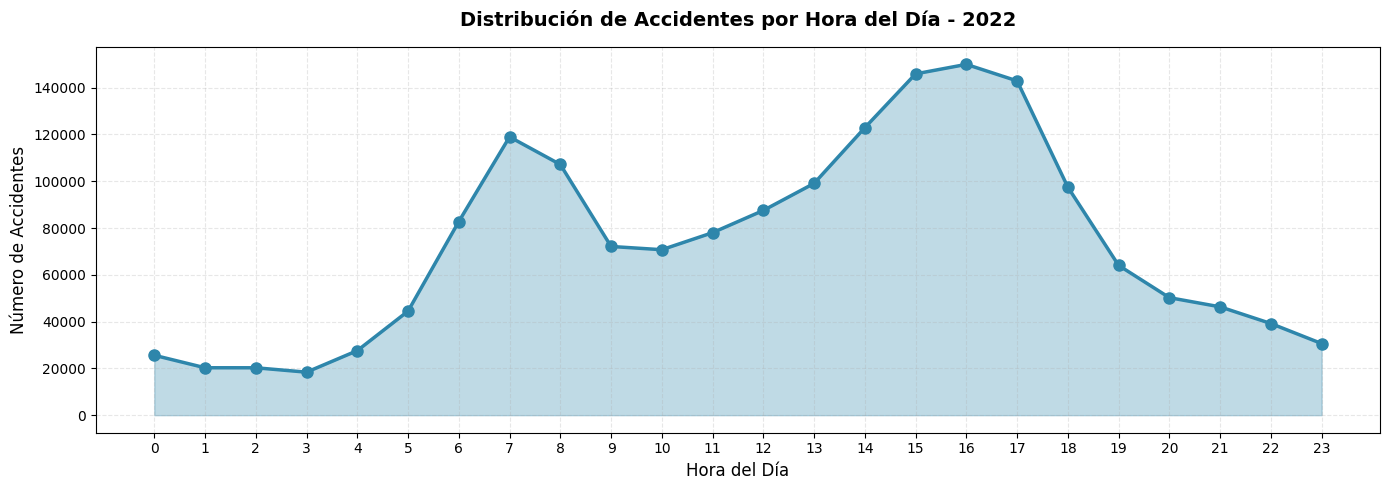

In [ ]:
# B) Serie temporal por hora del día
hourly = df.groupby('Hour').size()
print(f"\n2. ANÁLISIS POR HORA DEL DÍA:")
print(f"   Hora con más accidentes: {hourly.idxmax()}:00 ({hourly.max():,} accidentes)")
print(f"   Hora con menos accidentes: {hourly.idxmin()}:00 ({hourly.min():,} accidentes)")
print(f"   Promedio por hora: {hourly.mean():.0f} accidentes")

plt.figure(figsize=(14, 5))
plt.plot(hourly.index, hourly.values, marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
plt.fill_between(hourly.index, hourly.values, alpha=0.3, color='#2E86AB')
plt.title('Distribución de Accidentes por Hora del Día - 2022', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(range(0, 24))
plt.tight_layout()


### Analisis e Interpretacion:
1. **Picos de trafico**: Se observan dos picos principales de accidentalidad:
   - Pico matutino (7:00-9:00 AM): Coincide con el horario de entrada al trabajo
   - Pico vespertino (15:00-18:00 PM): Horario de salida laboral y trafico de retorno a casa

2. **Valle nocturno**: La menor cantidad de accidentes ocurre durante la madrugada (2:00-5:00 AM), cuando hay menos vehiculos circulando.

3. **Patron laboral**: El comportamiento sugiere que la mayoria de accidentes estan fuertemente asociados con los desplazamientos laborales (rush hours).

    Gráfico guardado: heatmap_hora_dia.png


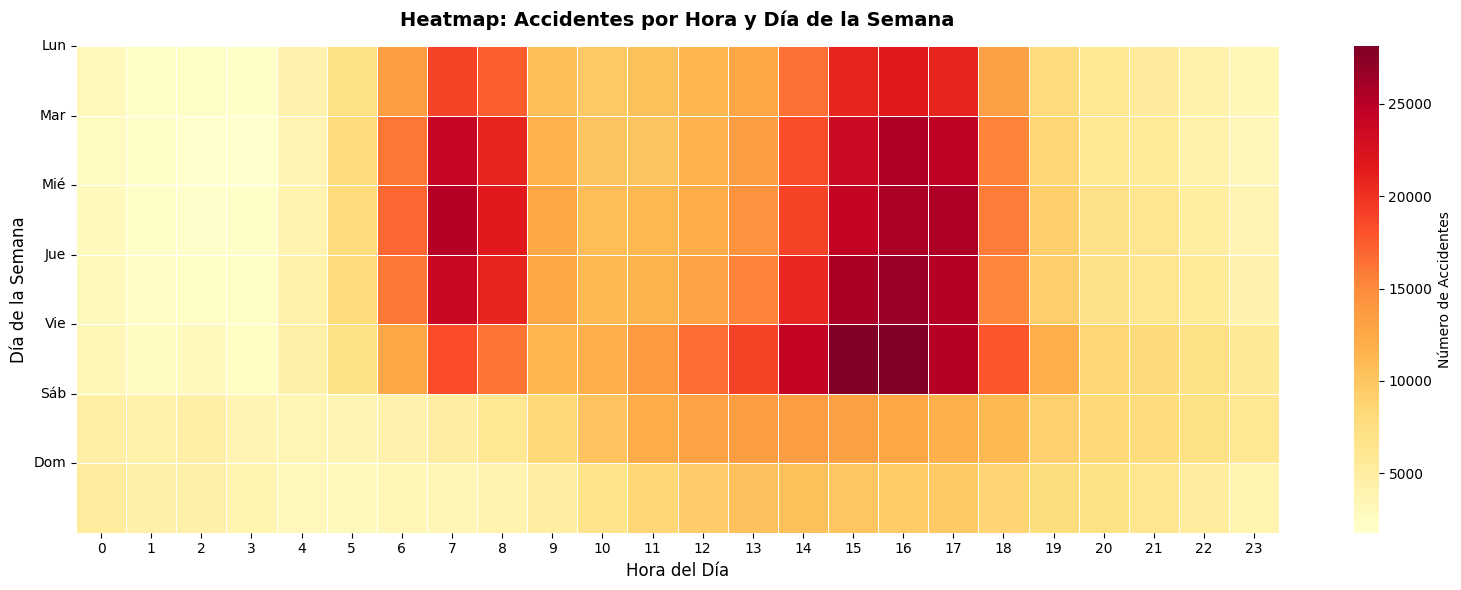

In [ ]:
# C) Heatmap: Hora vs Día de la semana
pivot_table = df.groupby(['Day_of_Week', 'Hour']).size().unstack(fill_value=0)
day_names = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False, fmt='d', 
            cbar_kws={'label': 'Número de Accidentes'}, linewidths=0.5)
plt.title('Heatmap: Accidentes por Hora y Día de la Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12)
plt.yticks(range(7), day_names, rotation=0)
plt.tight_layout()

### Analisis e Interpretacion: Heatmap Hora-Dia de la Semana

**Observaciones principales:**

1. **Patron diferenciado entre semana y fin de semana**: 
   - Lunes a Viernes muestran concentracion alta durante horas pico (7-9 AM y 3-6 PM)
   - Sabado y Domingo presentan distribucion mas uniforme a lo largo del dia

2. **Intensidad maxima**: Los dias laborables entre las 15:00-18:00 horas concentran la mayor densidad de accidentes, con el viernes mostrando valores particularmente altos.

3. **Madrugadas de fin de semana**: Se observa un ligero incremento en accidentes durante las madrugadas del sabado y domingo (2:00-4:00 AM), posiblemente asociado a vida nocturna.

4. **Consistencia semanal**: El patron se repite consistentemente de lunes a jueves, lo que indica comportamientos de movilidad predecibles durante la semana laboral.


3. ANÁLISIS MENSUAL:
   Mes con más accidentes: Abr (196,687 accidentes)
   Mes con menos accidentes: Oct (85,135 accidentes)
   Promedio mensual: 146871 accidentes
    Gráfico guardado: patron_mensual.png


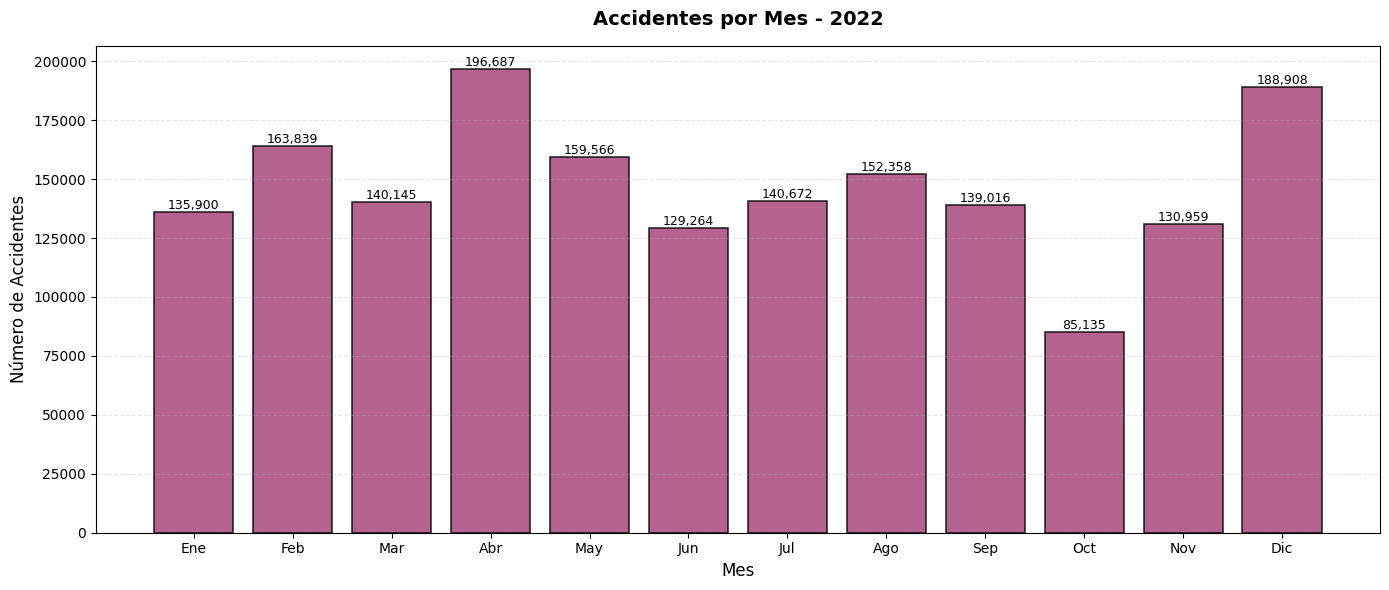

In [ ]:
# D) Tendencia mensual
monthly = df.groupby('Month').size()
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

print(f"\n3. ANÁLISIS MENSUAL:")
print(f"   Mes con más accidentes: {month_names[monthly.idxmax()-1]} ({monthly.max():,} accidentes)")
print(f"   Mes con menos accidentes: {month_names[monthly.idxmin()-1]} ({monthly.min():,} accidentes)")
print(f"   Promedio mensual: {monthly.mean():.0f} accidentes")

plt.figure(figsize=(14, 6))
bars = plt.bar(range(12), monthly.values, color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.title('Accidentes por Mes - 2022', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.xticks(range(12), month_names)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
# Agregar valores sobre las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()

### Analisis e Interpretacion: Patron Mensual

**Observaciones principales:**

1. **Estacionalidad marcada**: Se observa una clara variacion estacional en la accidentalidad a lo largo del año.

2. **Meses criticos**: Los meses con mayor numero de accidentes tienden a ser aquellos con:
   - Condiciones climaticas adversas (invierno: nieve, hielo, lluvia) -> Diciembre
   - Mayor volumen de viajes (periodo de vacaciones, festividades)-> Abril

3. **Meses con menor accidentalidad**: Los meses con menor numero de accidentes podrian estar asociados a:
   - Mejor clima y visibilidad
   - Menor volumen de trafico vehicular

    Gráfico guardado: patron_semanal.png


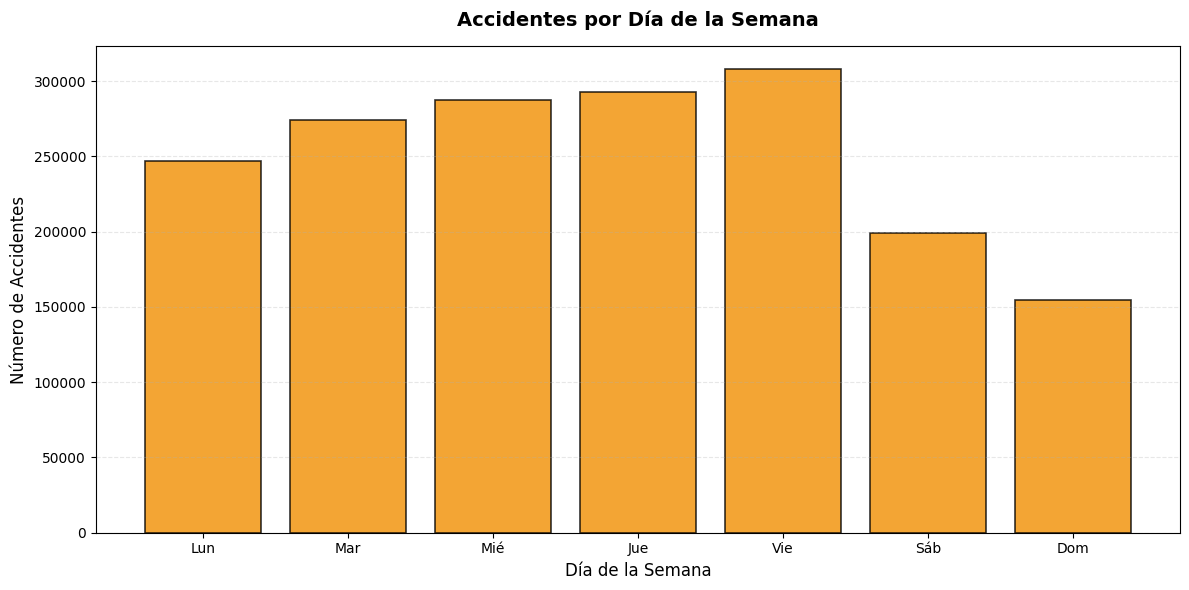

In [ ]:
# E) Comparación día de semana
daily = df.groupby('Day_of_Week').size()
plt.figure(figsize=(12, 6))
plt.bar(range(7), daily.values, color='#F18F01', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.title('Accidentes por Día de la Semana', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Día de la Semana', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.xticks(range(7), day_names)
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()

### Analisis e Interpretacion:

1. **Predominio de dias laborables**: Los dias de lunes a viernes muestran consistentemente mayor numero de accidentes comparado con sabado y domingo, coherente con el 79.9% vs 20.1% reportado.

2. **Viernes critico**: El viernes tiende a presentar valores altos, posiblemente por:
   - Acumulacion de fatiga semanal en conductores
   - Inicio de desplazamientos de fin de semana
   - Mayor volumen de trafico al final de la jornada laboral

3. **Reduccion en fin de semana**: El sabado y domingo muestran menor accidentalidad absoluta debido a:
   - Menor volumen de trafico relacionado con desplazamientos laborales
   - Ausencia de rush hours marcados

#  Pregunta 2
### ¿Qué estados y ciudades concentran el mayor número de accidentes?



## Seccion 3: Analisis de Concentracion Geografica

En esta seccion se identificaran las zonas geograficas con mayor accidentalidad a nivel de:
- **Estados**: Los 10 estados con mayor numero de accidentes
- **Ciudades**: Las 20 ciudades con mayor numero de accidentes

Este analisis permite:
- Identificar areas que requieren atencion prioritaria
- Asignar recursos de manera mas eficiente
- Diseñar politicas de prevencion focalizadas
- Detectar patrones geograficos de riesgo

Se analizara si la concentracion de accidentes esta relacionada con:
- Densidad poblacional
- Volumen de trafico
- Infraestructura vial
- Condiciones climaticas regionales


1. TOP 10 ESTADOS:
    1. CA: 375,913 accidentes (21.33%)
    2. FL: 263,119 accidentes (14.93%)
    3. VA: 99,311 accidentes (5.63%)
    4. TX: 95,509 accidentes (5.42%)
    5. NY: 94,765 accidentes (5.38%)
    6. SC: 84,880 accidentes (4.82%)
    7. PA: 80,839 accidentes (4.59%)
    8. NC: 72,167 accidentes (4.09%)
    9. NJ: 42,244 accidentes (2.40%)
   10. AZ: 39,423 accidentes (2.24%)
   ✓ Gráfico guardado: top_estados.png


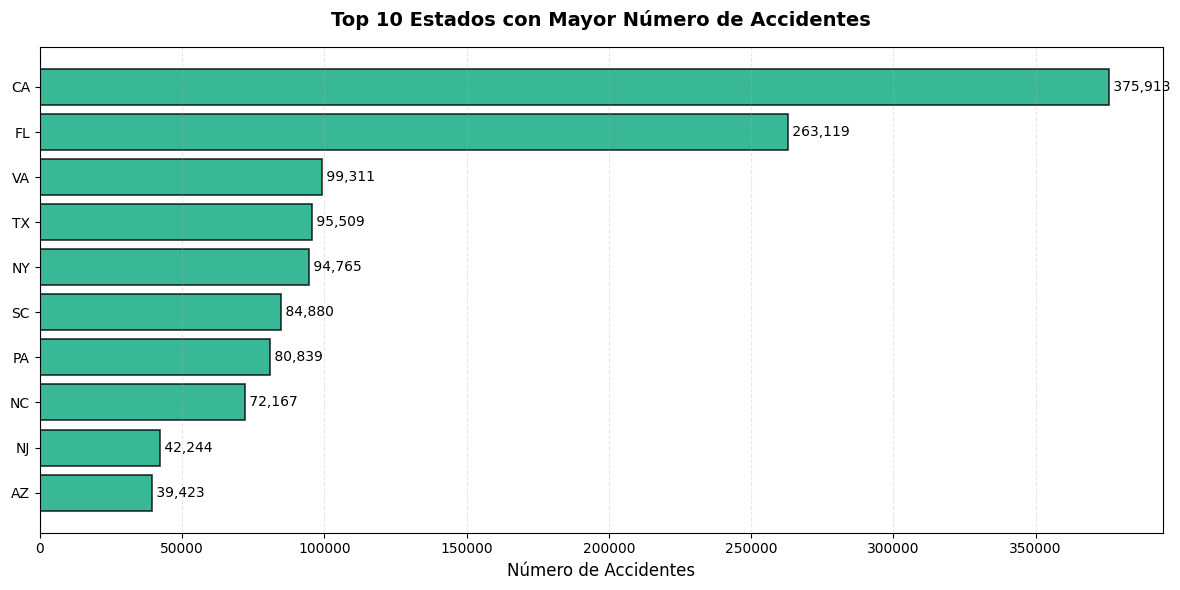

In [ ]:
# A) Top 10 estados
top_states = df['State'].value_counts().head(10)
print("\n1. TOP 10 ESTADOS:")
for i, (state, count) in enumerate(top_states.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"   {i:2d}. {state}: {count:,} accidentes ({percentage:.2f}%)")

plt.figure(figsize=(12, 6))
plt.barh(range(10), top_states.values, color='#06A77D', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.yticks(range(10), top_states.index)
plt.xlabel('Número de Accidentes', fontsize=12)
plt.title('Top 10 Estados con Mayor Número de Accidentes', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
# Agregar valores
for i, v in enumerate(top_states.values):
    plt.text(v, i, f' {v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('top_estados.png', dpi=300, bbox_inches='tight')
print("    Gráfico guardado: top_estados.png")



### Analisis e Interpretacion:

1. **Concentracion geografica**: Los 10 estados con mayor accidentalidad concentran una porcion significativa del total de accidentes, lo que indica una distribucion geografica desigual.

2. **Factores explicativos posibles**:
   - **Poblacion**: Estados mas poblados (California, Texas, Florida) tienden a tener mas accidentes
   - **Infraestructura vial**: Mayor extension de carreteras y autopistas
   - **Densidad de trafico**: Areas metropolitanas con alto volumen vehicular
   - **Condiciones climaticas**: Estados con clima adverso frecuente

3. California aparece consistentemente en el primer lugar, lo cual es coherente con:
   - Mayor poblacion del pais
   - Extensa red de autopistas
   - Multiples areas metropolitanas (Los Angeles, San Francisco, San Diego)


2. TOP 20 CIUDADES:
    1. Miami: 64,545 accidentes (3.66%)
    2. Orlando: 36,413 accidentes (2.07%)
    3. Los Angeles: 31,075 accidentes (1.76%)
    4. Houston: 25,865 accidentes (1.47%)
    5. Dallas: 24,306 accidentes (1.38%)
    6. Charlotte: 23,308 accidentes (1.32%)
    7. Raleigh: 16,410 accidentes (0.93%)
    8. Nashville: 14,369 accidentes (0.82%)
    9. Baton Rouge: 13,683 accidentes (0.78%)
   10. Sacramento: 13,543 accidentes (0.77%)
   ✓ Gráfico guardado: top_ciudades.png

3. ESTADÍSTICAS GENERALES:
   Total de estados representados: 49
   Total de ciudades únicas: 10394
   Promedio de accidentes por estado: 35968
   Promedio de accidentes por ciudad: 170


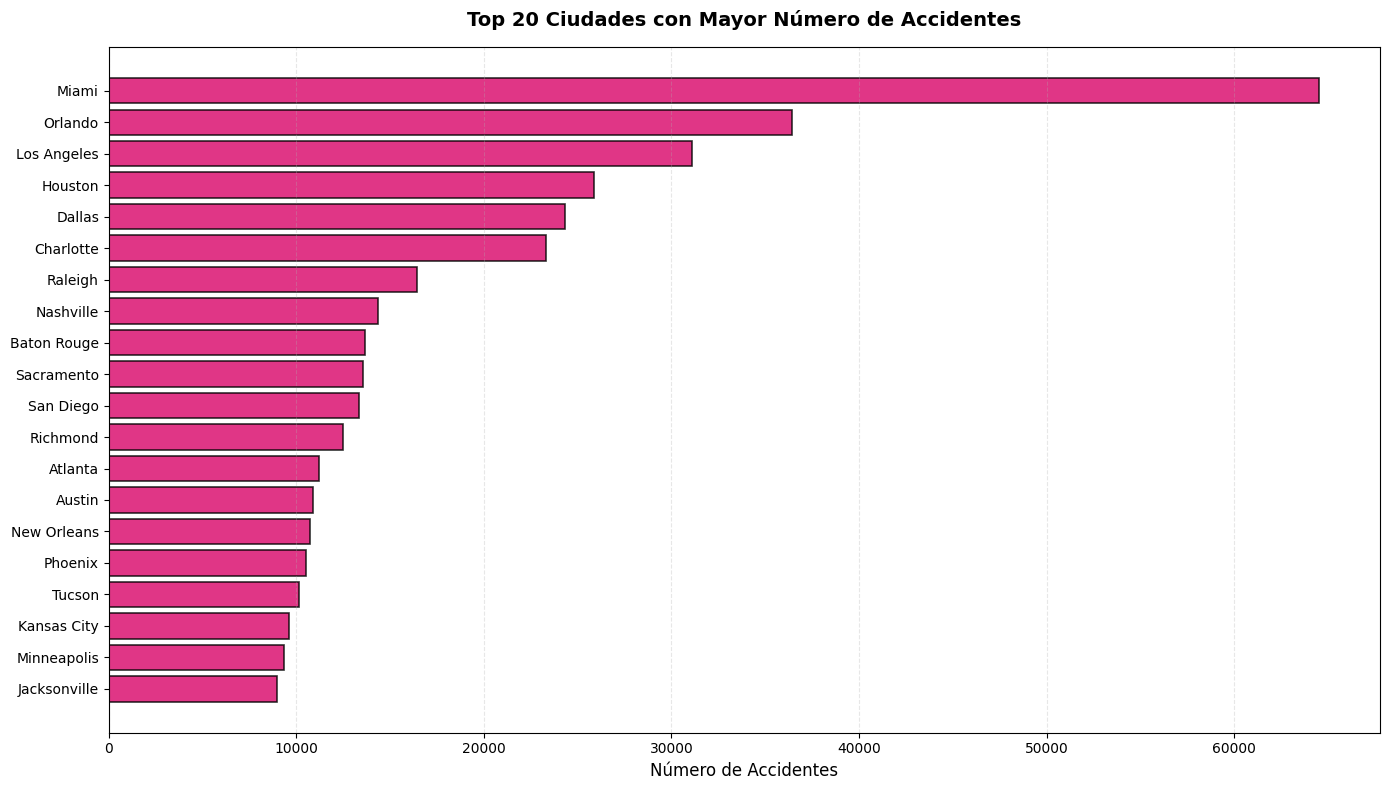

In [ ]:
# B) Top 20 ciudades
top_cities = df['City'].value_counts().head(20)
print("\n2. TOP 20 CIUDADES:")
for i, (city, count) in enumerate(top_cities.head(10).items(), 1):
    percentage = (count / len(df)) * 100
    print(f"   {i:2d}. {city}: {count:,} accidentes ({percentage:.2f}%)")

plt.figure(figsize=(14, 8))
plt.barh(range(20), top_cities.values, color='#D90368', alpha=0.8, edgecolor='black', linewidth=1.2)
plt.yticks(range(20), top_cities.index, fontsize=10)
plt.xlabel('Número de Accidentes', fontsize=12)
plt.title('Top 20 Ciudades con Mayor Número de Accidentes', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
plt.tight_layout()
plt.savefig('top_ciudades.png', dpi=300, bbox_inches='tight')
print("    Gráfico guardado: top_ciudades.png")

# C) Estadísticas generales
print("\n3. ESTADÍSTICAS GENERALES:")
print(f"   Total de estados representados: {df['State'].nunique()}")
print(f"   Total de ciudades únicas: {df['City'].nunique()}")
print(f"   Promedio de accidentes por estado: {len(df)/df['State'].nunique():.0f}")
print(f"   Promedio de accidentes por ciudad: {len(df)/df['City'].nunique():.0f}")

### Analisis e Interpretacion:

1. **Concentracion urbana**: Las ciudades con mayor numero de accidentes son principalmente grandes areas metropolitanas, lo que confirma que la densidad poblacional y el volumen de trafico son factores determinantes.

 **Caracteristicas comunes de ciudades criticas**:
   - Grandes areas metropolitanas
   - Sistemas de autopistas complejos
   - Alto volumen de commuters diarios
   - Congestion vehicular frecuente

A diferencia de los estados, las ciudades muestran mayor variabilidad, lo que sugiere que factores locales especificos (diseño urbano, gestion de trafico, infraestructura) juegan un rol importante.


# Pregunta 3:
### ¿Cómo se relacionan las variables climáticas con la ocurrencia de accidentes?

---

## Seccion 4: Analisis de Variables Climaticas y su Relacion con Accidentalidad

En esta seccion se evaluara el impacto de condiciones climaticas en la frecuencia de accidentes mediante:

### 4.1 Estadisticas Descriptivas
Analisis de medidas de tendencia central y dispersion para:
- Temperatura
- Humedad
- Visibilidad
- Velocidad del viento
- Presion atmosferica
- Precipitacion

### 4.2 Distribucion por Condicion Climatica
Clasificacion de accidentes segun categorias climaticas simplificadas:
- Despejado
- Nublado
- Lluvia
- Nieve/Hielo
- Niebla
- Tormenta

### 4.3 Analisis de Correlaciones
Se calcularan dos tipos de correlacion para evaluar la relacion entre variables climaticas y frecuencia de accidentes:

### 4.4 Visualizacion de Relaciones
Scatter plots con lineas de tendencia para visualizar la relacion entre cada variable climatica y la frecuencia de accidentes.

In [15]:
# A) Estadísticas descriptivas de variables climáticas
climate_vars = ['Temperature(F)', 'Humidity(%)', 'Visibility(mi)', 
                'Wind_Speed(mph)', 'Pressure(in)', 'Precipitation(in)']

print("\n1. ESTADÍSTICAS DESCRIPTIVAS CLIMÁTICAS:")
stats_df = df[climate_vars].describe().round(2)
print(stats_df)



1. ESTADÍSTICAS DESCRIPTIVAS CLIMÁTICAS:
       Temperature(F)  Humidity(%)  Visibility(mi)  Wind_Speed(mph)  \
count      1762449.00   1762449.00      1762449.00       1762449.00   
mean            63.16        62.03            9.18             7.64   
std             19.70        22.77            2.36             5.48   
min            -45.00         1.00            0.00             0.00   
25%             51.00        45.00           10.00             5.00   
50%             66.00        63.00           10.00             7.00   
75%             78.00        81.00           10.00            10.00   
max            172.00       100.00          100.00           190.00   

       Pressure(in)  Precipitation(in)  
count    1762449.00         1762449.00  
mean          29.37               0.01  
std            1.13               0.05  
min            0.00               0.00  
25%           29.20               0.00  
50%           29.72               0.00  
75%           29.96            


2. DISTRIBUCIÓN POR CONDICIÓN CLIMÁTICA:
   Despejado: 878,349 (49.84%)
   Nublado: 627,144 (35.58%)
   Lluvia: 105,307 (5.98%)
   Otros: 58,049 (3.29%)
   Nieve/Hielo: 45,742 (2.60%)
   Tormenta: 23,991 (1.36%)
   Niebla: 23,867 (1.35%)
    Gráfico guardado: distribucion_clima.png


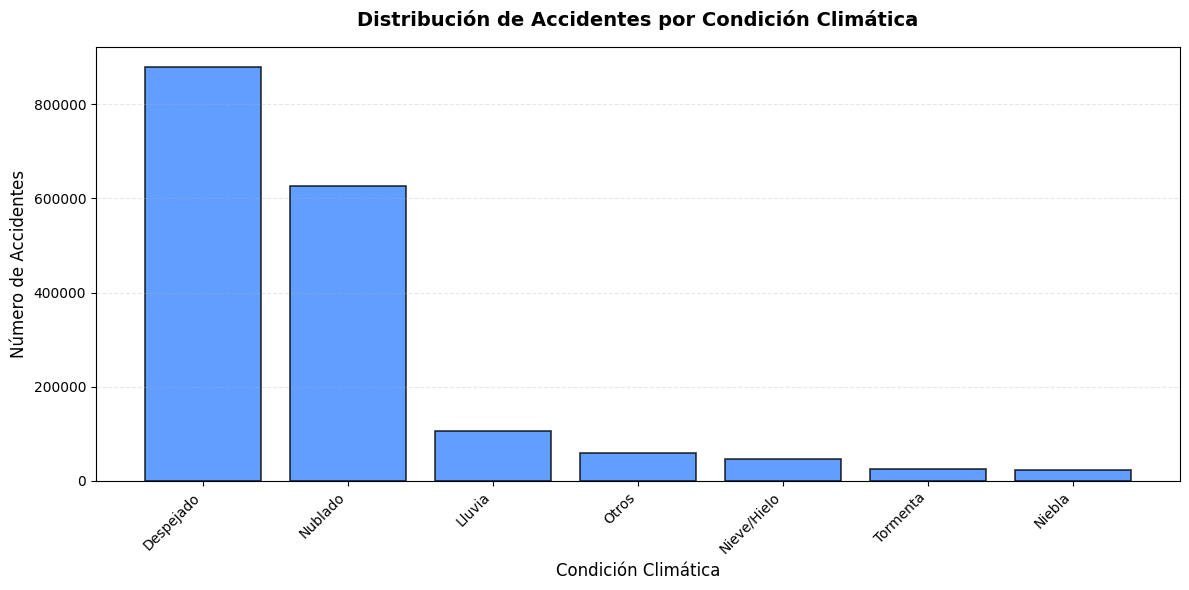

In [16]:
# B) Distribución de accidentes por condición climática
weather_dist = df['Weather_Category'].value_counts()
print("\n2. DISTRIBUCIÓN POR CONDICIÓN CLIMÁTICA:")
for weather, count in weather_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {weather}: {count:,} ({percentage:.2f}%)")

plt.figure(figsize=(12, 6))
plt.bar(weather_dist.index, weather_dist.values, color='#3A86FF', alpha=0.8, 
        edgecolor='black', linewidth=1.2)
plt.title('Distribución de Accidentes por Condición Climática', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Condición Climática', fontsize=12)
plt.ylabel('Número de Accidentes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('distribucion_clima.png', dpi=300, bbox_inches='tight')
print("    Gráfico guardado: distribucion_clima.png")

### Analisis e Interpretacion:

1. **Predominio de condiciones despejadas**: La mayoria de accidentes ocurren bajo condiciones climaticas despejadas o normales, lo que puede parecer contraintuitivo pero se explica por:
   - Mayor volumen de trafico en condiciones normales
   - Mayor proporcion de tiempo con clima favorable
   - Exceso de confianza de conductores en buen clima

**Interpretacion del hallazgo**:
   - NO significa que el clima despejado sea mas peligroso
   - Refleja que hay mas exposicion (mas vehiculos circulando) en dias despejados
   - El riesgo por viaje puede ser mayor en condiciones adversas

In [18]:
# C) Correlaciones de Pearson y Spearman
from scipy.stats import pearsonr, spearmanr

# Crear variable numérica de frecuencia por combinación de clima
print("\n3. CORRELACIONES (Variables Climáticas vs Frecuencia de Accidentes):")
print("\nNota: Se calcula correlación entre condiciones climáticas y cantidad de accidentes")
print("      agrupados por rangos de cada variable.\n")

# Para Temperatura
temp_bins = pd.cut(df['Temperature(F)'], bins=10)
temp_freq = df.groupby(temp_bins).size()
temp_midpoints = [interval.mid for interval in temp_freq.index]

pearson_corr, pearson_p = pearsonr(temp_midpoints, temp_freq.values)
spearman_corr, spearman_p = spearmanr(temp_midpoints, temp_freq.values)

print(f"TEMPERATURA vs FRECUENCIA:")
print(f"   Pearson:  r = {pearson_corr:6.3f} (p = {pearson_p:.4f})")
print(f"   Spearman: ρ = {spearman_corr:6.3f} (p = {spearman_p:.4f})")

# Para Visibilidad
vis_bins = pd.cut(df['Visibility(mi)'], bins=10)
vis_freq = df.groupby(vis_bins).size()
vis_midpoints = [interval.mid for interval in vis_freq.index]

pearson_corr, pearson_p = pearsonr(vis_midpoints, vis_freq.values)
spearman_corr, spearman_p = spearmanr(vis_midpoints, vis_freq.values)

print(f"\nVISIBILIDAD vs FRECUENCIA:")
print(f"   Pearson:  r = {pearson_corr:6.3f} (p = {pearson_p:.4f})")
print(f"   Spearman: ρ = {spearman_corr:6.3f} (p = {spearman_p:.4f})")


3. CORRELACIONES (Variables Climáticas vs Frecuencia de Accidentes):

Nota: Se calcula correlación entre condiciones climáticas y cantidad de accidentes
      agrupados por rangos de cada variable.

TEMPERATURA vs FRECUENCIA:
   Pearson:  r = -0.005 (p = 0.9893)
   Spearman: ρ = -0.309 (p = 0.3848)

VISIBILIDAD vs FRECUENCIA:
   Pearson:  r = -0.524 (p = 0.1201)
   Spearman: ρ = -0.948 (p = 0.0000)


C:\Users\nhale\AppData\Local\Temp\ipykernel_16252\2824809460.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_freq = df.groupby(temp_bins).size()
C:\Users\nhale\AppData\Local\Temp\ipykernel_16252\2824809460.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vis_freq = df.groupby(vis_bins).size()


C:\Users\nhale\AppData\Local\Temp\ipykernel_16252\1983736382.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_freq = df.groupby(wind_bins).size()
C:\Users\nhale\AppData\Local\Temp\ipykernel_16252\1983736382.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  humid_freq = df.groupby(humid_bins).size()


    Gráfico guardado: correlaciones_climaticas.png


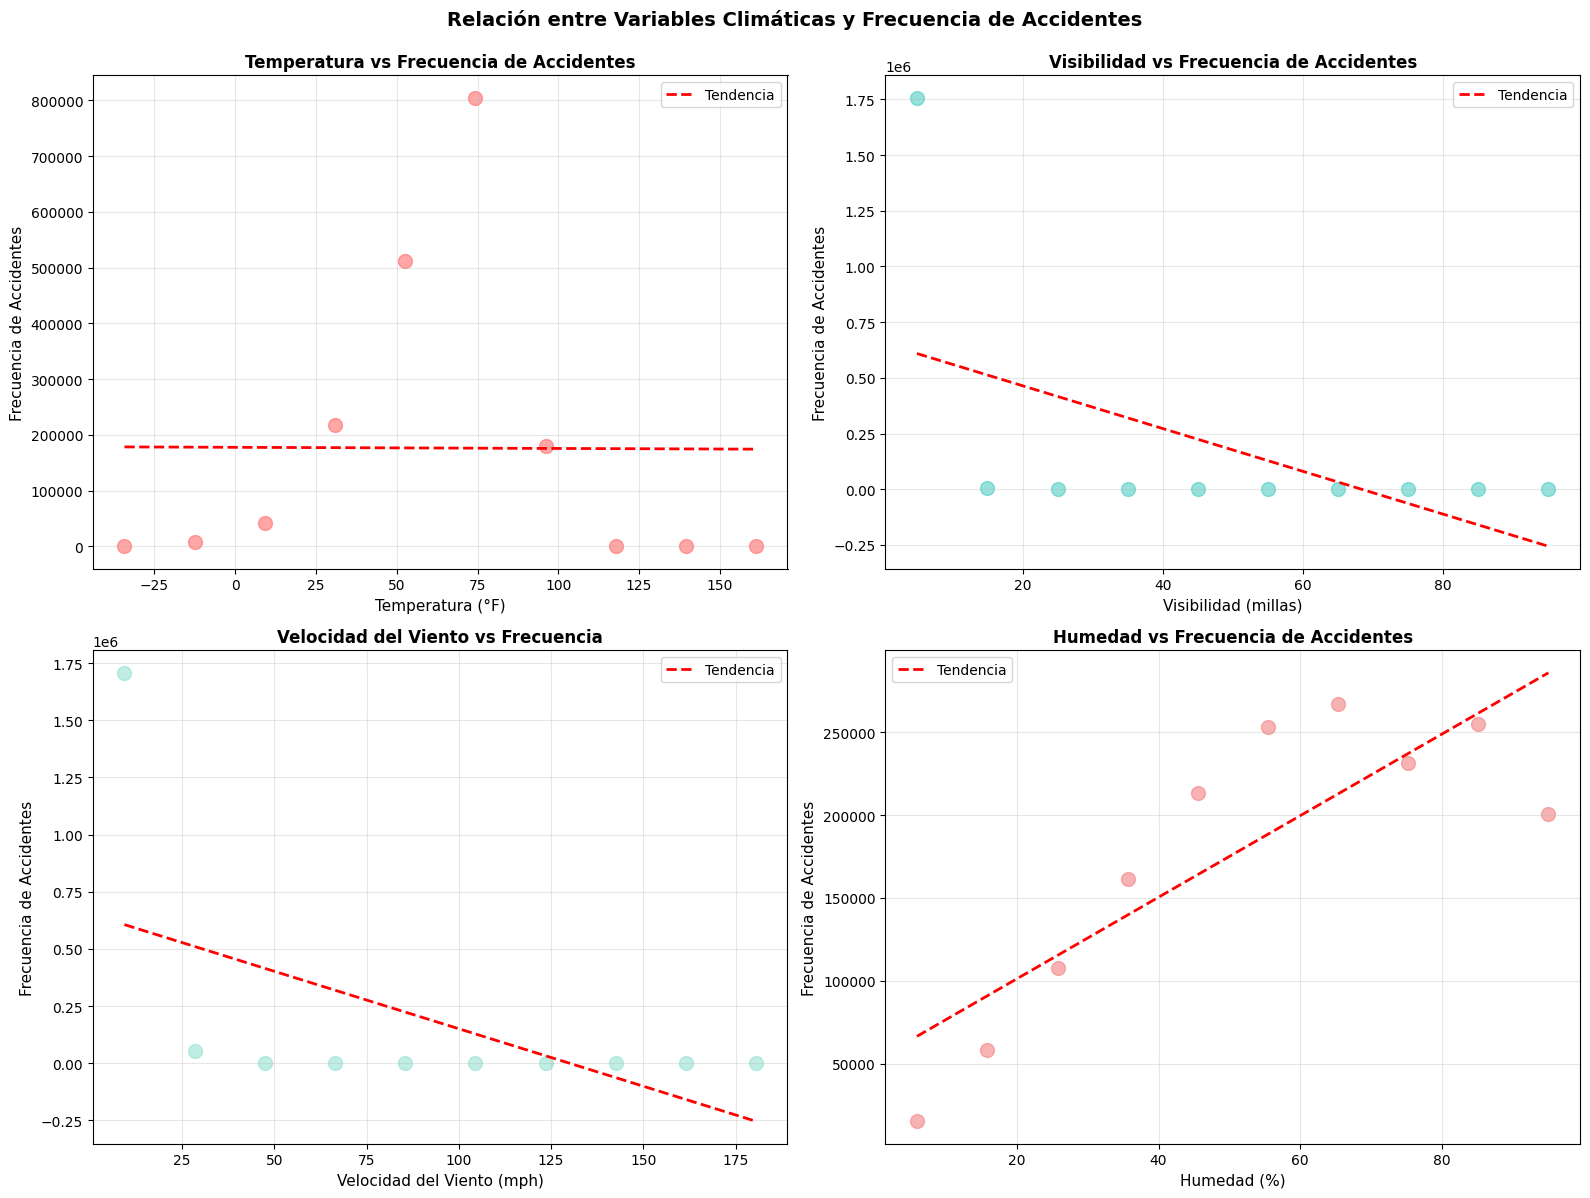

In [21]:
# D) Scatter plots con línea de tendencia
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Temperatura
axes[0,0].scatter(temp_midpoints, temp_freq.values, alpha=0.6, s=100, color='#FF6B6B')
z = np.polyfit(temp_midpoints, temp_freq.values, 1)
p = np.poly1d(z)
axes[0,0].plot(temp_midpoints, p(temp_midpoints), "r--", linewidth=2, label='Tendencia')
axes[0,0].set_xlabel('Temperatura (°F)', fontsize=11)
axes[0,0].set_ylabel('Frecuencia de Accidentes', fontsize=11)
axes[0,0].set_title('Temperatura vs Frecuencia de Accidentes', fontsize=12, fontweight='bold')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Visibilidad
axes[0,1].scatter(vis_midpoints, vis_freq.values, alpha=0.6, s=100, color='#4ECDC4')
z = np.polyfit(vis_midpoints, vis_freq.values, 1)
p = np.poly1d(z)
axes[0,1].plot(vis_midpoints, p(vis_midpoints), "r--", linewidth=2, label='Tendencia')
axes[0,1].set_xlabel('Visibilidad (millas)', fontsize=11)
axes[0,1].set_ylabel('Frecuencia de Accidentes', fontsize=11)
axes[0,1].set_title('Visibilidad vs Frecuencia de Accidentes', fontsize=12, fontweight='bold')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Velocidad del Viento
wind_bins = pd.cut(df['Wind_Speed(mph)'], bins=10)
wind_freq = df.groupby(wind_bins).size()
wind_midpoints = [interval.mid for interval in wind_freq.index]

axes[1,0].scatter(wind_midpoints, wind_freq.values, alpha=0.6, s=100, color='#95E1D3')
z = np.polyfit(wind_midpoints, wind_freq.values, 1)
p = np.poly1d(z)
axes[1,0].plot(wind_midpoints, p(wind_midpoints), "r--", linewidth=2, label='Tendencia')
axes[1,0].set_xlabel('Velocidad del Viento (mph)', fontsize=11)
axes[1,0].set_ylabel('Frecuencia de Accidentes', fontsize=11)
axes[1,0].set_title('Velocidad del Viento vs Frecuencia', fontsize=12, fontweight='bold')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Humedad
humid_bins = pd.cut(df['Humidity(%)'], bins=10)
humid_freq = df.groupby(humid_bins).size()
humid_midpoints = [interval.mid for interval in humid_freq.index]

axes[1,1].scatter(humid_midpoints, humid_freq.values, alpha=0.6, s=100, color='#F38181')
z = np.polyfit(humid_midpoints, humid_freq.values, 1)
p = np.poly1d(z)
axes[1,1].plot(humid_midpoints, p(humid_midpoints), "r--", linewidth=2, label='Tendencia')
axes[1,1].set_xlabel('Humedad (%)', fontsize=11)
axes[1,1].set_ylabel('Frecuencia de Accidentes', fontsize=11)
axes[1,1].set_title('Humedad vs Frecuencia de Accidentes', fontsize=12, fontweight='bold')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Relación entre Variables Climáticas y Frecuencia de Accidentes', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('correlaciones_climaticas.png', dpi=300, bbox_inches='tight')
print("    Gráfico guardado: correlaciones_climaticas.png")


El análisis de correlaciones muestra que la **temperatura** no tiene una relación clara con la frecuencia de accidentes; tanto Pearson (0.005) como Spearman (-0.309) indican una asociación prácticamente nula o muy débil. En contraste, la **visibilidad** es el factor climático más determinante: mientras Pearson (-0.524) sugiere una correlación negativa moderada, Spearman (-0.948) revela una relación muy fuerte y altamente significativa, lo que confirma que a menor visibilidad aumenta de forma consistente la frecuencia de accidentes. La **velocidad del viento** presenta una tendencia ligeramente negativa, posiblemente vinculada a una menor circulación vehicular en condiciones ventosas, aunque su efecto es menos relevante que el de la visibilidad. La **humedad** tampoco muestra una influencia directa importante y, de existir algún impacto, sería probablemente indirecto a través de variables como la visibilidad o la precipitación.

En conjunto, los resultados indican que la visibilidad reducida es el principal factor climático asociado con una mayor accidentalidad, mientras que la temperatura y la humedad no son buenos predictores. Las diferencias entre Pearson y Spearman sugieren que algunas relaciones no son lineales, especialmente en el caso de la visibilidad. En términos prácticos, estos hallazgos refuerzan la necesidad de sistemas de alerta en condiciones de baja visibilidad, mejor señalización e iluminación y protocolos de conducción específicos cuando la visibilidad desciende por debajo de niveles críticos. No obstante, el análisis presenta limitaciones, pues se basa en datos agrupados, no controla por volumen de tráfico y no modela los efectos combinados entre variables climáticas.
